# Reproduce Figure 3 from Hu & van Leeuwen (2021)

Comparison of scalar kernel vs matrix-valued kernel in PFF

- x^(19): UNOBSERVED component
- x^(20): OBSERVED component  
- Black circles: Prior ensemble (before assimilation)
- Red circles: Posterior ensemble (after assimilation)

Expected: Scalar kernel collapses in observed direction, matrix kernel maintains spread.


In [60]:
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path


In [61]:
# Load results from experiments
output_dir = Path('../outputs')

with open(output_dir / 'lorenz96_kernel_matrix' / 'summary.json', 'r') as f:
    matrix_summary = json.load(f)

with open(output_dir / 'lorenz96_kernel_scalar' / 'summary.json', 'r') as f:
    scalar_summary = json.load(f)
    
print("Loaded matrix and scalar kernel results")


Loaded matrix and scalar kernel results


In [62]:
# Load particle arrays from .npy files
# First time step (t=20) is index 0

prior_matrix = np.load(output_dir / 'lorenz96_kernel_matrix' / 'prior_particles.npy')[0]
posterior_matrix = np.load(output_dir / 'lorenz96_kernel_matrix' / 'posterior_particles.npy')[0]

prior_scalar = np.load(output_dir / 'lorenz96_kernel_scalar' / 'prior_particles.npy')[0]
posterior_scalar = np.load(output_dir / 'lorenz96_kernel_scalar' / 'posterior_particles.npy')[0]

print(f"Prior shape: {prior_matrix.shape}")
print(f"Posterior shape: {posterior_matrix.shape}")


Prior shape: (20, 1000)
Posterior shape: (20, 1000)


In [63]:
# Extract x^(19) and x^(20)
# Python 0-indexing: x^(19) = index 18, x^(20) = index 19
idx_unobs = 18  # x^(19) - unobserved
idx_obs = 19    # x^(20) - observed (indices 3,7,11,15,19,...)

# Matrix kernel
prior_x19_matrix = prior_matrix[:, idx_unobs]
prior_x20_matrix = prior_matrix[:, idx_obs]
posterior_x19_matrix = posterior_matrix[:, idx_unobs]
posterior_x20_matrix = posterior_matrix[:, idx_obs]

# Scalar kernel  
prior_x19_scalar = prior_scalar[:, idx_unobs]
prior_x20_scalar = prior_scalar[:, idx_obs]
posterior_x19_scalar = posterior_scalar[:, idx_unobs]
posterior_x20_scalar = posterior_scalar[:, idx_obs]


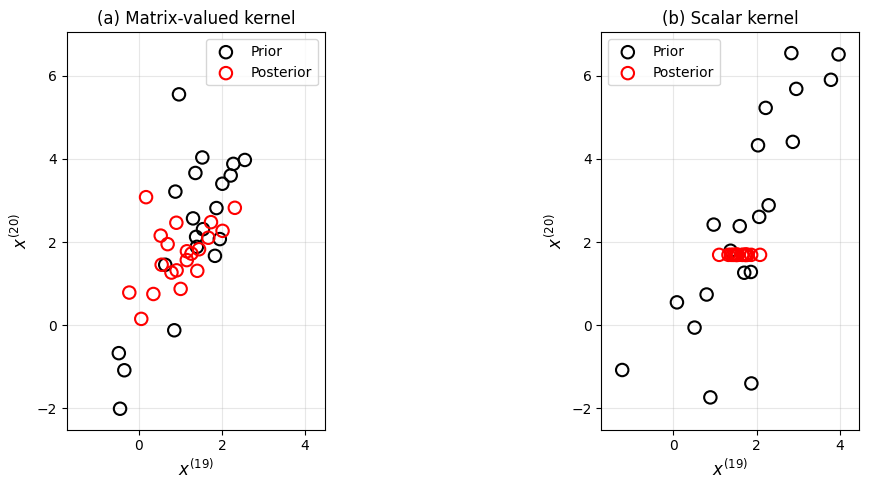

In [64]:
# Create Figure 3
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Matrix-valued kernel
ax = axes[0]
ax.scatter(prior_x19_matrix, prior_x20_matrix, s=80, facecolors='none', 
           edgecolors='black', linewidths=1.5, label='Prior', zorder=2)
ax.scatter(posterior_x19_matrix, posterior_x20_matrix, s=80, 
           facecolors='none', edgecolors='red', linewidths=1.5, 
           label='Posterior', zorder=3)
ax.set_xlabel(r'$x^{(19)}$', fontsize=12)
ax.set_ylabel(r'$x^{(20)}$', fontsize=12)
ax.set_title('(a) Matrix-valued kernel', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# (b) Scalar kernel
ax = axes[1]
ax.scatter(prior_x19_scalar, prior_x20_scalar, s=80, facecolors='none', 
           edgecolors='black', linewidths=1.5, label='Prior', zorder=2)
ax.scatter(posterior_x19_scalar, posterior_x20_scalar, s=80, 
           facecolors='none', edgecolors='red', linewidths=1.5, 
           label='Posterior', zorder=3)
ax.set_xlabel(r'$x^{(19)}$', fontsize=12)
ax.set_ylabel(r'$x^{(20)}$', fontsize=12)
ax.set_title('(b) Scalar kernel', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Match axis limits
all_x19 = np.concatenate([prior_x19_matrix, posterior_x19_matrix, 
                          prior_x19_scalar, posterior_x19_scalar])
all_x20 = np.concatenate([prior_x20_matrix, posterior_x20_matrix,
                          prior_x20_scalar, posterior_x20_scalar])
margin = 0.5
xlim = [all_x19.min() - margin, all_x19.max() + margin]
ylim = [all_x20.min() - margin, all_x20.max() + margin]

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('figure3_reproduction.png', dpi=300, bbox_inches='tight')
plt.show()
